# ¡Hola Elizabeth! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v4 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Elizabeth, ¿cómo estás? Espero que estés bien y avanzando con tranquilidad.

Felicitaciones por haber completado correctamente todos los ítems del notebook. El desarrollo está bien hecho y cumple con los requerimientos principales. Lo único que falta es la creación de un repositorio donde expliques el contexto de este análisis y lo realizado aquí. Revisa el comentario que dejé al final del notebook.

Si necesitas ayuda o tienes alguna pregunta, puedes dejarla en azul, estaré encantado de responderla en la siguiente revisión.

¡Saludos!


</div>

----

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, numpy as np

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Ojo con importar seaborn como sb, típicamente, por no decir siempre, se usa sns como abreviación.



</div>

In [46]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [47]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [48]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [49]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, muy bien con la carga de la data y la muestra de sus primeras filas. El uso de `head()` es útil para tener un vistazo rápido del inicio del notebook. Por defecto, muestra las primeras 5 filas, si se usa `head(n)` mostrará las primeras n filas.


</div>

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [50]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [51]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [52]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [53]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, muy bien con el uso de `info()` para revisar las filas de los dataframes, nota que nos muestra la cantidad de nulos de cada columna. Además, al usar `shape`, podemos ver la cantidad de filas y columnas.


</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [54]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [55]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Bien hecho. Al usar `.isna()`, tendremos una marca de True o False para cada fila de cada columna, indicando si la fila es nula o no. Luego, al aplicar `.sum()`, se contarán los Trues de cada columna, es decir, en el resultado tenemos la cantidad de nulos para cada columna. Por otro lado, al aplicar `.mean()`, se tendrá el porcentaje de filas nulas.




</div>

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    Las columnas de user_id, id y type para la columna de usage junto con la de user_id, first_name, last_name, plan, age y reg_date dentro de users se muestran como nulos
- Indica qué harías: ¿imputar, eliminar, ignorar?
Dado que los valores nulos son entre el 80% y el 90%, se sugiere ignorar ya que, para otro posible análisis más adelante podría ser necesario el uso de dichas columnas.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [56]:
# explorar columnas numéricas de users
columnas_user = ['user_id', 'age']
users[columnas_user].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` podemos visualizar los datos sobre porcentajes de la cantidad de usuarios contenidos, así como los parámetros numéricos de esto. La totalidad de los usuarios es de 13999
- La columna `age` al igual que la anterior, nos da los parámetros para diferentes tipos de variables siendo 79 años el mayor valor registrado

In [57]:
# explorar columnas numéricas de usage
columnas_usage = ['id', 'user_id']
usage[columnas_usage].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

El uso de `describe()` es adecuado para entender el rango de los datos de cada columna, bien hecho. Además, se puede indicar los percentiles que se quieren ver, al hacer `describe(percentiles=[0.1,0.5,0.99])` por ejemplo, podremos ver los percentiles 10%, 50% y 99%.



</div>

- Las columnas `id` y `user_id` podemos observar la manera en que los usuarios en general, se comportan para el uso del sistema de telecomunicaciones, podemos darnos cuenta que el crecimiento en porcentaje de uso de usuarios es constante.

In [58]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe() 

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` nos esta indicando como la ciudad que esta hasta arriba en usuarios es Bogotá así como diversos parámetros a considerar de esta.
- La columna `plan` al igual que la anterior, se reflejan las mismas categorías indicando que el plan que esta hasta arriba es el básico.

In [59]:
# explorar columna categórica de usage
usage['type'].head()
usage['type'].value_counts()
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Excelente, con `value_counts()` tenemos un conteo de cuantas veces aparece cada uno de los diferentes valores de la columna. Ojo que por defecto `value_counts()` no muestra los nulos, si quisieras además que cuente los nulos, se requiere usar el parámetro `dropna=False` dentro de la función.


</div>

- La columna `type` nos muestra cuantas veces esta catalogado el tipo en dicha base de datos, así como el tipo que es más popular.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  La columna de age en users trae valores negativos.
- ¿Qué acción tomarías?  Es necesario reemplazar los valores negativos por valores nulos

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [60]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
print("Tipo antes:", users['reg_date'].dtype)
print("Primeros valores:")
print(users['reg_date'].head())

Tipo antes: datetime64[ns]
Primeros valores:
0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [61]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
print("Tipo antes:", usage['date'].dtype)
print("Primeros valores:")
print(usage['date'].head())

Tipo antes: datetime64[ns]
Primeros valores:
0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, bien con el uso de `pd.to_datetime` para realizar la conversión a datetime de las columnas que contienen fechas. Bien al agregar `errors='coerce'` como parámetro, si hay una fila que no está en formato fecha, quedará como nulo.


</div>

In [62]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, podemos observar los primeros valores que datan en 2022 pero, todos señalan que son de la misma fecha a diferente hora. Las fechas que indican listadas son de 2022 a 2026

In [63]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto, muy bien con el uso de `dt.year`. Dado que anteriormente convertimos la columna de fecha a tipo datetime, en esta parte podemos usar ese atributo para obtener rápidamente el año.


</div>

En `date`, los primeros valores datan únicamente de 2024, sin ebargo, en los registros viene que tenemos valores de 2024 e indica que hay valores faltantes.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) lo que aparece es una faltante en date-usage.
- ¿Qué harías con ellas? Creo que existe un problema de llenado de datos desde el sistema original, no se puede omitir ya que podría ser importante, es necesario que definamos que se quiere llegar a analizar para determinar si podemos prescindir de ese dato.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [64]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Correcto el reemplazo. Haces muy bien al seleccionar la mediana de los datos que no tienen -999, para luego reemplazar los -999 por la mediana calculada.


</div>

In [65]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [66]:
# Marcar fechas futuras como NA para reg_date
fecha_min = pd.to_datetime('2020-01-01')
fecha_max = pd.to_datetime('2026-12-31')
mask_fuera_rango = (users['reg_date'] < fecha_min) | (users['reg_date'] > fecha_max)
users.loc[mask_fuera_rango, 'reg_date'] = pd.NaT

# Verificar cambios

print(f"Fechas fuera de rango marcadas como nulas: {mask_fuera_rango.sum()}")
print(f"Total de valores nulos en reg_date: {users['reg_date'].isna().sum()}")

Fechas fuera de rango marcadas como nulas: 0
Total de valores nulos en reg_date: 0


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Correcto, muy bien con la marca. Haces bien en usar específicamente `NaT` para marcar nulos en una columna de datetime.



</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [67]:
# Verificación MAR en usage (Missing At Random) para duration
duration_missing = users['churn_date'].isnull()
print("Nulos en 'churn_date' por plan:")
print(pd.crosstab(users['plan'], duration_missing, margins=True))
print()

Nulos en 'churn_date' por plan:
churn_date  False  True   All
plan                         
Basico        298  2297  2595
Premium       168  1237  1405
All           466  3534  4000



In [68]:
# Verificación MAR en usage (Missing At Random) para length
length_missing = usage['length'].isnull()
print("Nulos en 'length' por tipo:")
print(pd.crosstab(usage['type'], length_missing, margins=True))

Nulos en 'length' por tipo:
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho, muy bien con el conteo de nulos por type. 



</div>

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [69]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': ['sum', 'count', 'mean'],
    'is_call': ['sum', 'count', 'mean'],
    'duration': ['sum'] 
}).reset_index()


# observar resultado
usage_agg.head(3)

user_id is_text                 is_call                 duration
              sum count      mean     sum count      mean      sum
0   10000       7    10  0.700000       3    10  0.300000    23.70
1   10001       5    15  0.333333      10    15  0.666667    33.18
2   10002       5     7  0.714286       2     7  0.285714    10.74

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

En esta parte falta generar la columna de duración de llamadas. Usa la columna de duration y realiza las agregaciones correspondientes.



</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v3        </b> <a class="tocSkip"></a>

Bien hecho, corregido



</div>

In [70]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

user_id cant_mensajes                 cant_llamadas                  \
                    sum count      mean           sum count      mean   
0   10000             7    10  0.700000             3    10  0.300000   
1   10001             5    15  0.333333            10    15  0.666667   
2   10002             5     7  0.714286             2     7  0.285714   

  cant_minutos_llamada  
                   sum  
0                23.70  
1                33.18  
2                10.74

In [71]:
# Combinar la tabla agregada con el dataset de usuarios
df_merged = pd.merge(
    users,
    usage_agg,
    on=['user_id'],
    how='left'
)
users.head(5)

/.venv/lib/python3.9/site-packages/pandas/core/reshape/merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/pandas/core/generic.py:4153: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [72]:
# Resumen estadístico de las columnas numéricas
print("Resumen estadístico de las columnas numéricas:")
df_merged.describe()

Resumen estadístico de las columnas numéricas:


,user_id,age,"(cant_mensajes, sum)","(cant_mensajes, count)","(cant_mensajes, mean)","(cant_llamadas, sum)","(cant_llamadas, count)","(cant_llamadas, mean)","(cant_minutos_llamada, sum)"
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,10.002501,0.553062,4.478120,10.002501,0.446938,23.317054
std,1154.844867,17.689919,2.358416,3.191878,0.166437,2.144238,3.191878,0.166437,18.168095
min,10000.000000,18.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,8.000000,0.444444,3.000000,8.000000,0.333333,11.120000
50%,11999.500000,48.000000,5.000000,10.000000,0.555556,4.000000,10.000000,0.444444,19.780000
75%,12999.250000,63.000000,7.000000,12.000000,0.666667,6.000000,12.000000,0.555556,31.415000
max,13999.000000,79.000000,17.000000,27.000000,1.000000,15.000000,27.000000,1.000000,155.690000


In [73]:
# Distribución porcentual del tipo de plan
porcentajes = df_merged['plan'].value_counts(normalize=True) * 100
print(porcentajes)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

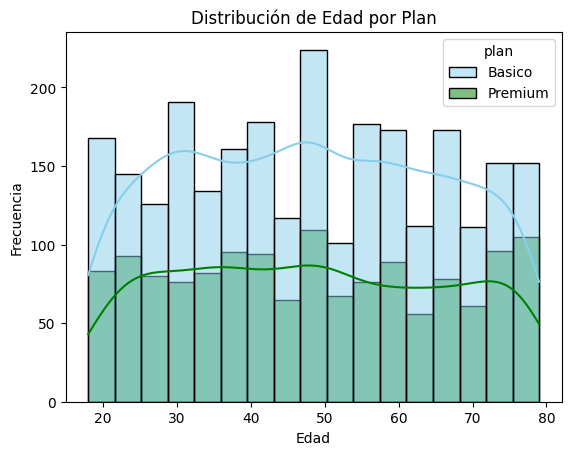

In [74]:
# Histograma para visualizar la edad (age)
sns.histplot(data=df_merged, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad por Plan')
plt.show()

💡Insights: 
- Podemos percatarnos que tanto para el plan Premium como para el plan Basico la frecuencia esta más alta para los usuarios con edad de 50 años siguiendole la gente de 30.

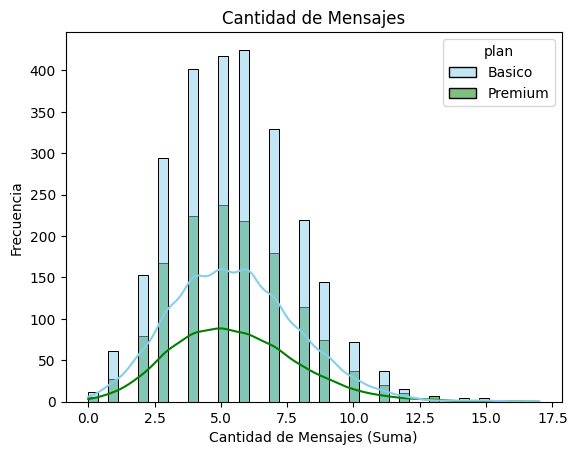

In [75]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=df_merged, x=('cant_mensajes', 'sum'), hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de Mensajes (Suma)')
plt.ylabel('Frecuencia')
plt.title('Cantidad de Mensajes')
plt.show()


💡Insights: 
- Podemos observar que la frecuencia tiende a subir entre los 5.0 y 7.5 de mensajes para ambos tipos de planes. La diferencia entre el uso del envío de mensajes de acuerdo al plan contratado varia muy poco por lo que se puede decir que para ambos planes registran el uso de dicho servicio en la misma proporción.

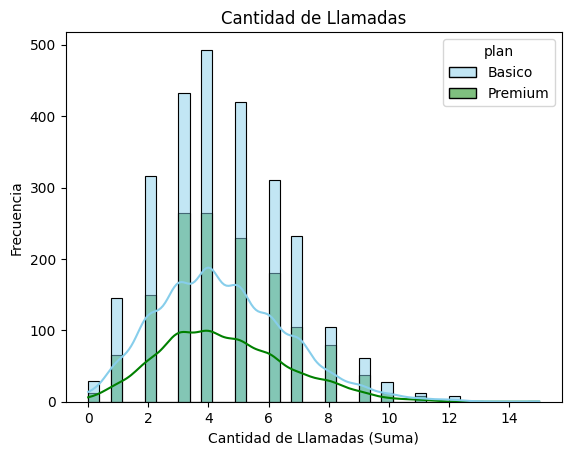

In [76]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=df_merged, x=('cant_llamadas', 'sum'), hue='plan', palette=['skyblue','green'], kde=True)

plt.xlabel('Cantidad de Llamadas (Suma)')
plt.ylabel('Frecuencia')
plt.title('Cantidad de Llamadas')
plt.show()


💡Insights: 
- Podemos observar que la cantidad de llamadas es más frecuente en el plan premium, si bien es una referencia media en cantidad, para el tema de frecuencia se puede visualizar que el plan premium da una mayor facilidad para realizar ese tipo de servicio.

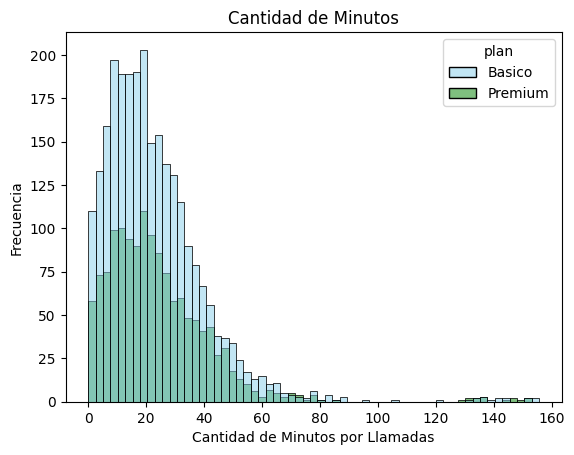

In [77]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=df_merged, x=('cant_minutos_llamada', 'sum'), hue='plan', palette=['skyblue','green'], kde=False)
plt.xlabel('Cantidad de Minutos por Llamadas')
plt.ylabel('Frecuencia')
plt.title('Cantidad de Minutos')
plt.show()


<div class="alert alert-block alert-danger">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Más arriba te indiqué dónde deberías generar la cantidad de minutos de llamadas por grupo. Con ello, basta replicar el mismo código que para estos gráficos y podrás realizar el histograma de minutos de llamadas.



</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor    v3      </b> <a class="tocSkip"></a>


Excelente, muy bien realizados los gráficos, el uso de `histplot` está perfecto!


</div>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

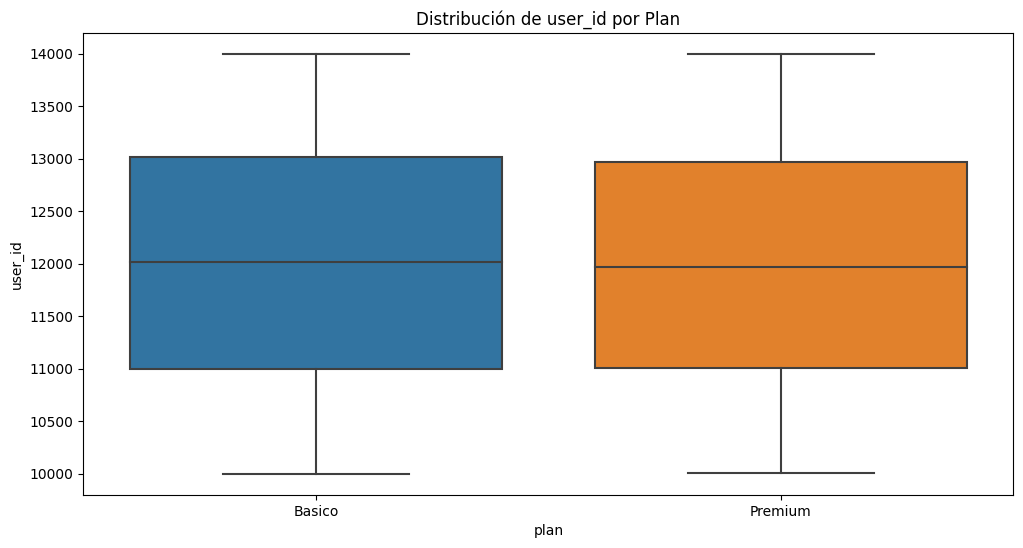

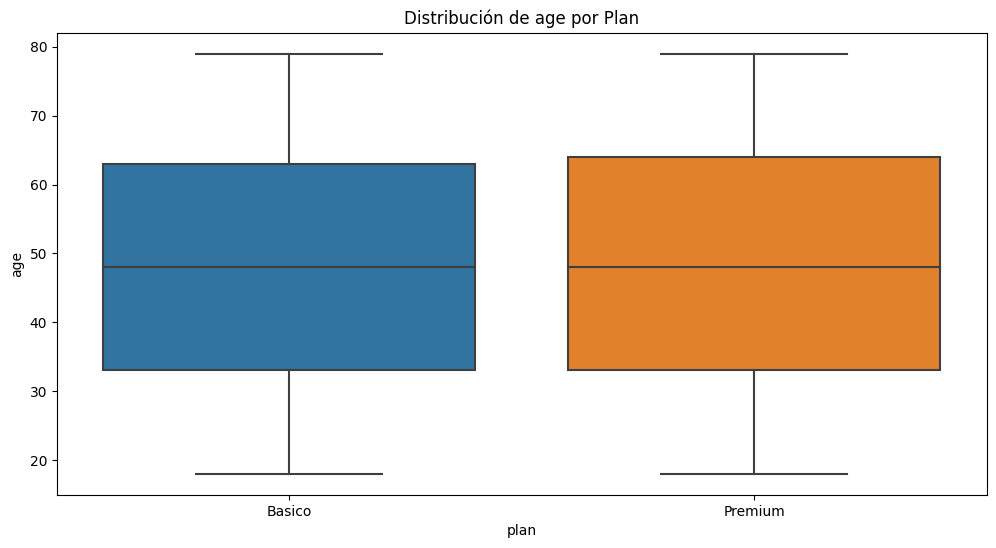

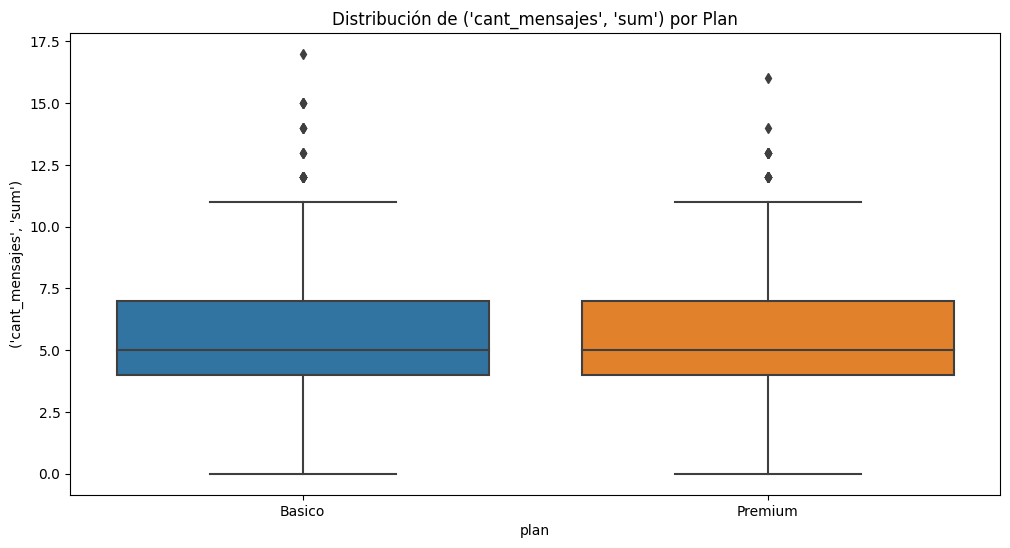

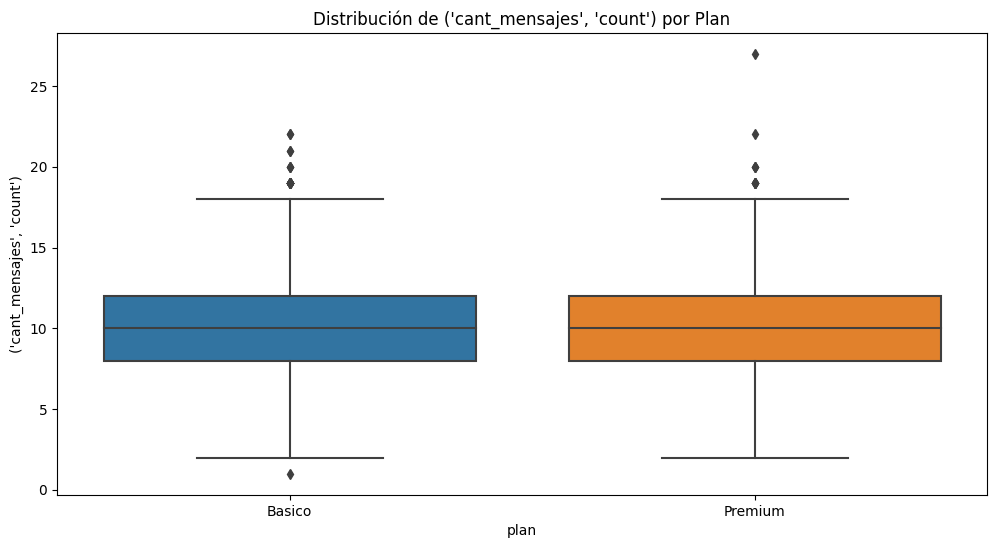

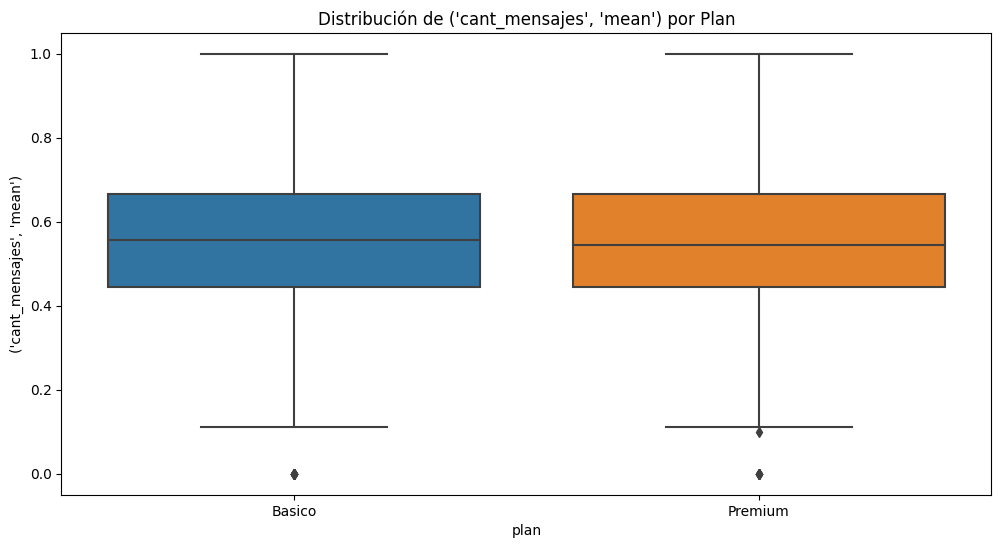

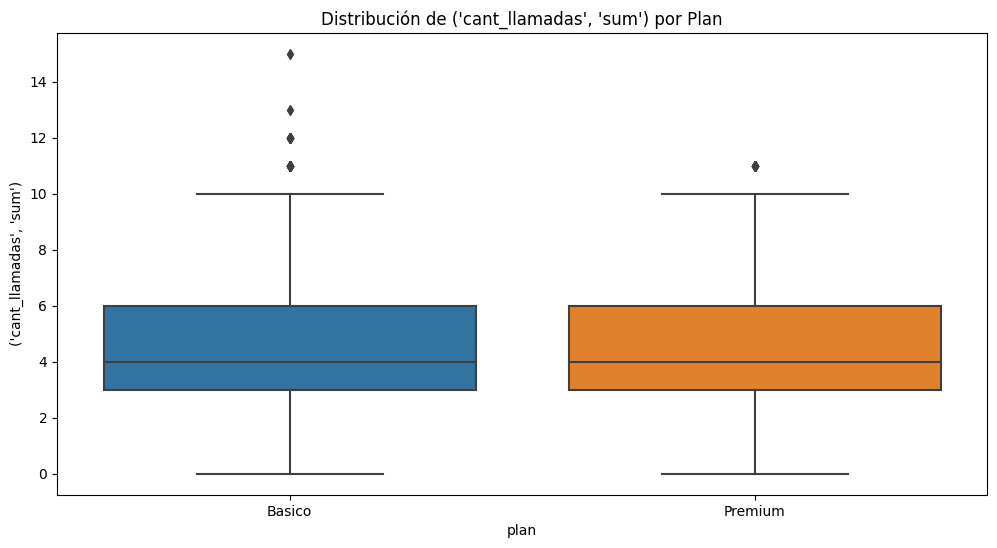

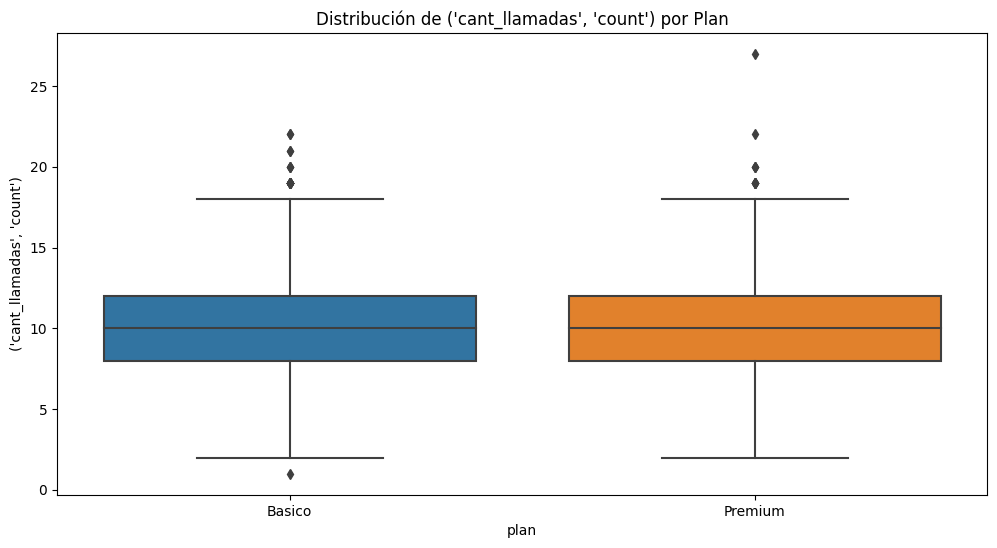

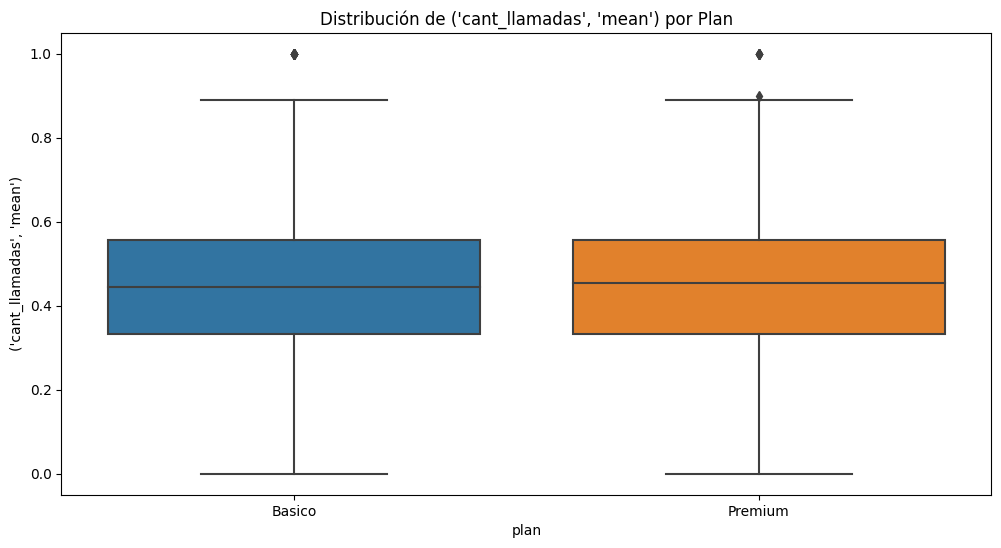

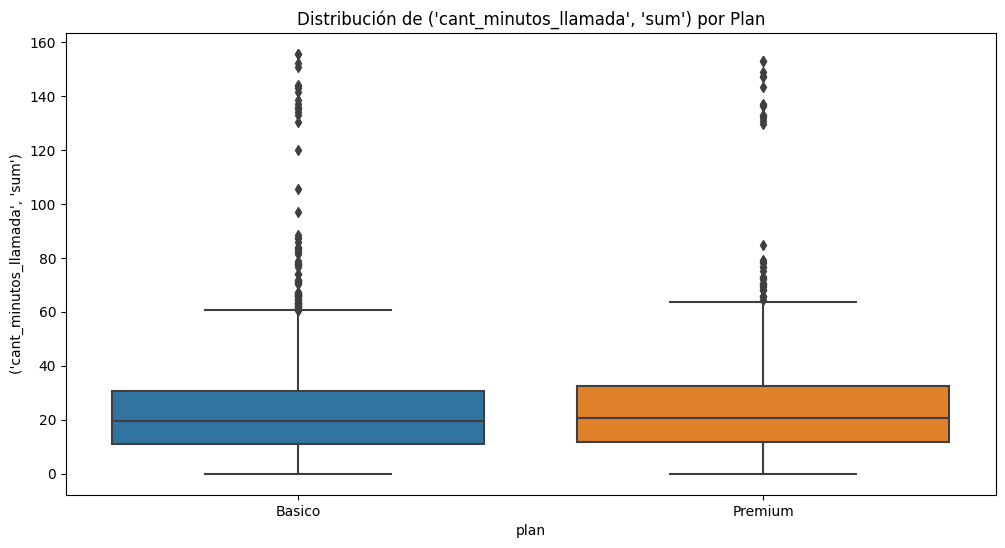

In [78]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in df_merged.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_merged, x='plan', y=columna)
    plt.title(f'Distribución de {columna} por Plan')
    plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de Revisor       v3   </b> <a class="tocSkip"></a>


Buen trabajo con los gráficos de boxplot, vemos rápidamente los outliers de cada variable.


</div>

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [79]:


# Calcular límites con el método IQR

columnas_limites = ['is_text', 'is_call', 'duration']
def calcular_limites_iqr(usage, columnas_limites):
    Q1 = usage[columnas_limites].quantile(0.25)
    Q3 = usage[columnas_limites].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    return limite_inferior, limite_superior, Q1, Q3, IQR




In [80]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
usage[columnas_limites].describe()


,is_text,is_call,duration
count,40000.000000,40000.000000,17924.000000
mean,0.552300,0.447700,5.202237
std,0.497263,0.497263,6.842701
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.437500
50%,1.000000,0.000000,3.500000
75%,1.000000,1.000000,6.990000
max,1.000000,1.000000,120.000000


💡Insights: 
- cant_mensajes: No es necesario excluir ningun valor ya que se denotan valores bajos congruentes con la medición sobre la cantidad de mensajes registradas. 
- cant_llamadas: No es necesario excluir ningun valor ya que se denotan valores bajos congruentes con la medición sobre la cantidad de llamadas registradas. 
- cant_minutos_llamada: A pesar de que se visualizan números altos, esto puede ser resultado de usuarios reales que realizan llamadas largas ya sea en el ámbito social o bien, familiar, también existen personas que pueden estar llevando a cabo conferencias telefonicas para diferentes aspectos como el tema laboral.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v4     </b> <a class="tocSkip"></a>


Excelente, muy bien con las decisiones. 

Respecto a minutos de llamadas estoy muy de acuerdo con lo que comentas. Si bien hay valores de tipo outlier muy grande, tampoco son valores que parezcan irreales (por ejemplo 150 minutos son 2 horas y media, algo que no se ve imposible). Por otro lado, cabe destacar que los outliers del gráfico se dividen naturalmente en dos grupos, por lo que eso también motiva a explorarlos más a fondo.


</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [95]:
# Crear columna grupo_uso

def clasificar_uso(row):
    if row ['cant_llamadas', 'sum'] < 5 and row ['cant_mensajes', 'sum'] < 5:
        return 'Bajo uso'

    elif row ['cant_llamadas', 'sum'] < 10 and row ['cant_mensajes', 'sum'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'

df_merged ['grupo_uso'] = df_merged.apply(clasificar_uso, axis =1)


In [97]:

# verificar cambios
df_merged.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,"(cant_mensajes, sum)","(cant_mensajes, count)","(cant_mensajes, mean)","(cant_llamadas, sum)","(cant_llamadas, count)","(cant_llamadas, mean)","(cant_minutos_llamada, sum)",grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,10.0,0.700000,3.0,10.0,0.300000,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,15.0,0.333333,10.0,15.0,0.666667,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,7.0,0.714286,2.0,7.0,0.285714,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,14.0,0.785714,3.0,14.0,0.214286,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,7.0,0.571429,3.0,7.0,0.428571,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [98]:
# Crear columna grupo_edad

def clasificar_grupo(row):
    if row ['age'] < 30:
        return 'Joven'

    elif row ['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

df_merged ['grupo_edad'] = df_merged.apply(clasificar_grupo, axis =1)


In [99]:
# verificar cambios
df_merged.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,"(cant_mensajes, sum)","(cant_mensajes, count)","(cant_mensajes, mean)","(cant_llamadas, sum)","(cant_llamadas, count)","(cant_llamadas, mean)","(cant_minutos_llamada, sum)",grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,10.0,0.700000,3.0,10.0,0.300000,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,15.0,0.333333,10.0,15.0,0.666667,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,7.0,0.714286,2.0,7.0,0.285714,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,14.0,0.785714,3.0,14.0,0.214286,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,7.0,0.571429,3.0,7.0,0.428571,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

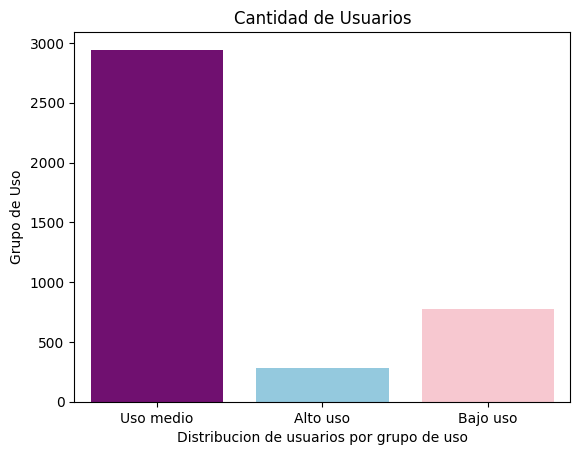

In [102]:
# Visualización de los segmentos por uso
sns.countplot(data= df_merged, x='grupo_uso', palette =['purple', 'skyblue', 'pink'])
plt.xlabel('Distribucion de usuarios por grupo de uso')
plt.ylabel('Grupo de Uso')
plt.title('Cantidad de Usuarios')
plt.show()

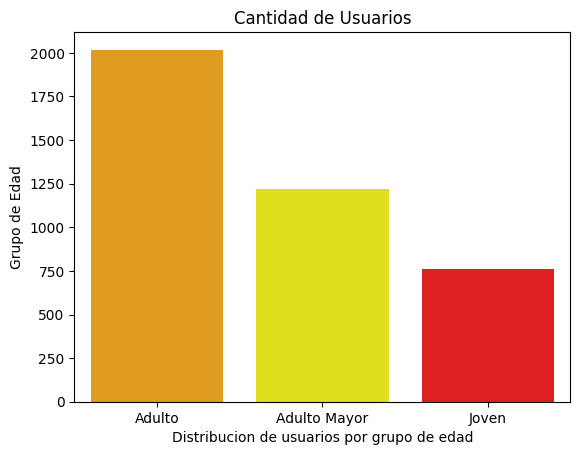

In [103]:
# Visualización de los segmentos por edad
sns.countplot(data= df_merged, x='grupo_edad', palette =['orange', 'yellow', 'red'])
plt.xlabel('Distribucion de usuarios por grupo de edad')
plt.ylabel('Grupo de Edad')
plt.title('Cantidad de Usuarios')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de Revisor    v4      </b> <a class="tocSkip"></a>


Excelente, muy bien realizados los gráficos, el uso de `histplot` está perfecto!


</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
El problema inicial de los datos versa en la forma en la que se encontraban organizados. El nombre de las columnas podría resultar confuso. Adicional, probalemente sea mejor segmentar aún mas las variables ya que los valores ahí mostrados traen demasiados decimales.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Identificados los segmentos por uso y por edad. Por uso, se determinó por la cantidad de llamadas y de mensajes en el cual, se puede visualizar que existe un uso medio en los usuarios registrados refiriendonos a uso medio cuando las llamadas y los mensajes son menores a 10 pero mayores a 5. Ahora bien, para el segmento de edades, se pudo visualizar que los adutlos son quienes ocupan en mayor proporción los servicios, es decir, aquellas personas entre 30 y 60 años.
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Definitivamente los adultos (entre 30 y 60 años) con casi una cantidad de 2,000 usuarios mientras que le siguen los adultos mayores (mayor a 60 años) con una cantidad de 1250 usuarios.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se encontraron outliers en el conteno de cantidad de minutos por llamadas, con una cifra de hasta 120 minutos. Esto podría significar que los usuarios estan utilizando el servicio para realizar llamadas largas lo que puede significar el uso para perfiles corporativos y laborales.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Se puede detectar que las personas que más utilizan los servicios son adultos de entre 30 y 60 años, adicional a que se detecta un uso alto registrado en cantidad de minutos por el servicio por lo que se puede inferir que quienes se encuentran utilizando más el servicio son personas que realizan constantemente llamadas pudiendo atribuir esto a conferencias laborales. Ahora bien, valdría la pena realizar una segmentación más a detalle para saber exactamente dentro del nivel de adulto, que servicios se estan utilizando realmente. Se podría crear un plan mpas atractivo para jovenes ofrenciendo redes sociales ilimitadas o GB de internet gratuitos.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Demasiados decimales en cifras
- Falta de especificacion en nombres de columnas para mayor claridad


🔍 **Segmentos por Edad**
- Adulto (30 a 60 años): Se registra una alta cantidad de usuarios llegando a los 2000
- Adulto Mayor (+ 60 años): Se registra una cantidad media de 1250 ususarios
- Jovenes (menos de 30 años): Se registran menos de 1000 usuarios


📊 **Segmentos por Nivel de Uso**
- Medio Uso: Se registra uso medio por un resultado de 3000 usuarios
- Alto Uso: Se registra uso en menos de 500 usuarios
- Bajo Uso: Se registra uso en casi 1000 usuarios


➡️ Esto sugiere que las personas que más utilizan el servicio son personas adultas y a un nivel ejecutivo toda vez que se registra un número de minutos por llamadas alto.


💡 **Recomendaciones**
- Realizar un análisis de datos dentro del grupo de personas adultas para revisar que tipo de servicio se esta utilizando más. Cabe lugar a que la cantidad de llamadas por minutos alto sea por un conteno global
-  Promocionar más planes con promociones pudiendo ofrecer redes ilimitadas o internet gratuito para poder llamar la atención de los segmentos más jovenes

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v4       </b> <a class="tocSkip"></a>


Buen trabajo con el análisis ejecutivo, se responden las principales inquietudes.
    
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`